# Descriptive Secondary Analysis of Kyber, Dilithium and Falcon Timing Data

Companion to the revised automotive-communication manuscript. This notebook analyzes reported timing values; it does not validate an automotive testbed, a real-time deadline, or FIPS compliance of the unknown implementations.

**Source context.** Gonçalves and Reis Quietinho Leithardt (2026), Mendeley Data V1, DOI [10.17632/czx6vk5hsr.1](https://data.mendeley.com/datasets/czx6vk5hsr/1). The landing page describes an OMNeT++ simulation using Veins-Inet and Veins. The host hardware, library versions, instrumentation, and distinction between simulated time and host elapsed time remain unverified.

**Data supplied here.** The tidy CSV is retained unchanged from the user's original archive. It has 1,376 records and 48 cells. Its checksum establishes this package's input identity, not authenticity of the original measurement experiment. The 48 reference means and five packet totals were retained from the supplied v2 notebook; their transcription from source PDFs has not been independently checked.

**Scope.** Figures 3–15 are recalculated from these data or the declared packet constants. Figures 1–2 are conceptual schematics, not a reconstruction of an observed testbed. The manuscript's existing graphics are retained; generated figures need not be pixel-identical. Table 1 is a curated literature comparison, not generated from the CSV.

## 0. Environment and execution

Use Python 3.12 and the accompanying `requirements.txt` in a fresh environment:

```sh
python -m venv .venv
# Activate .venv using the command appropriate to your operating system.
python -m pip install -r requirements.txt
python -m jupyter nbconvert --to notebook --execute PQC_Automotive_Analysis_revised.ipynb --output PQC_Automotive_Analysis_executed.ipynb --ExecutePreprocessor.timeout=180
```

Run from this package directory. The tested/default input is `pqc_tidy_timings.csv`. Outputs are written under `analysis_outputs/`. See README for validation limits and the optional raw-manifest schema. A clean Jupyter execution is distinct from sequential execution of code cells; the validation record states which was performed.

In [1]:
import os, glob, csv, sys, platform, warnings
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch

matplotlib.rcParams.update({
    "figure.dpi":120,"savefig.dpi":200,"font.size":11,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,
    "grid.alpha":0.25,"grid.linewidth":0.6,"axes.axisbelow":True})
print("python    ", sys.version.split()[0], "on", platform.platform())
print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", matplotlib.__version__)
from pathlib import Path
import json, hashlib, io, math
BASE = Path.cwd()
OUT = BASE / "analysis_outputs"
OUT.mkdir(exist_ok=True)
INPUT_MODE = "tidy"  # raw requires an explicit, locally verified raw_manifest.json
VALIDATION = {"original_experiment": "NOT_VERIFIED", "source_pdf_transcription": "NOT_VERIFIED"}
fig_counter = 0
def export_show(*args, **kwargs):
    global fig_counter
    for number in plt.get_fignums():
        fig_counter += 1
        fig = plt.figure(number)
        fig.savefig(OUT / f"figure_{fig_counter:02d}.png", dpi=200, bbox_inches="tight")
        fig.savefig(OUT / f"figure_{fig_counter:02d}.pdf", bbox_inches="tight")
        display(fig)
    plt.close("all")
plt.show = export_show
VERSIONS = {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "matplotlib": matplotlib.__version__}
(OUT / "environment.json").write_text(json.dumps(VERSIONS, indent=2))

python     3.12.14 on macOS-26.6.2-arm64-arm-64bit
numpy      2.5.3
pandas     2.2.3
matplotlib 3.11.2


92

## 1. Load and validate an explicitly identified input

The default tidy CSV is checked against the package manifest before parsing. Original source-record identifiers cannot be reconstructed: `source_row` below refers to the supplied tidy CSV only. Duplicate timing values are retained.

Optional raw mode requires a manifest listing each file, its SHA-256, scenario, algorithm, operation, and column-to-variant mapping. No directory-name inference is used. No original raw files are bundled or claimed to have been tested. Summary rows are rejected unless explicitly excluded by physical line number in the manifest. Malformed rows and non-finite/non-positive times fail loudly.

In [2]:
REQUIRED = ["scenario", "algorithm", "operation", "variant", "time_us"]
VARIANTS = {"Kyber": ["Kyber-512", "Kyber-768", "Kyber-1024"],
            "Dilithium": ["Dilithium-44", "Dilithium-65", "Dilithium-87"],
            "Falcon": ["Falcon-512", "Falcon-1024"]}
OPS = {"Kyber": ["KeyGen", "Encapsulation", "Decapsulation"],
       "Dilithium": ["KeyGen", "Signing", "Verification"],
       "Falcon": ["KeyGen", "Signing", "Verification"]}
def sha256(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def require(condition, message):
    if not condition: raise ValueError(message)

def validate_labels(frame):
    require(set(REQUIRED).issubset(frame.columns), "Missing required columns")
    require(not frame[REQUIRED].isna().any().any(), "Missing data in required fields")
    require(set(frame.scenario).issubset({"V2V", "V2X"}), "Unknown scenario")
    times = pd.to_numeric(frame.time_us, errors="raise")
    require(np.isfinite(times).all() and (times > 0).all(), "Timing must be finite and positive")
    frame = frame.copy(); frame["time_us"] = times
    for r in frame.itertuples():
        require(r.algorithm in VARIANTS, "Unknown algorithm")
        require(r.variant in VARIANTS[r.algorithm], "Variant/family mismatch")
        require(r.operation in OPS[r.algorithm], "Operation/family mismatch")
    return frame

def parse_raw_manifest(manifest_path):
    mp = Path(manifest_path).resolve(); manifest = json.loads(mp.read_text())
    records = []; excluded = []; paths = set()
    require(manifest.get("schema_version") == 1 and manifest.get("files"), "Invalid raw manifest")
    for item in manifest["files"]:
        path = (mp.parent / item["path"]).resolve()
        require(path.is_relative_to(mp.parent), "Raw path escapes manifest directory")
        require(path not in paths, "Duplicate raw file in manifest"); paths.add(path)
        require(sha256(path) == item["sha256"], f"Checksum mismatch: {path.name}")
        scenario, algorithm, operation = item["scenario"], item["algorithm"], item["operation"]
        mapping = item["columns"]
        require(len(set(mapping.values())) == len(mapping), "Duplicate variant mapping")
        skip = {int(k):v for k,v in item.get("exclude_rows", {}).items()}
        require(all(k >= 2 and str(v).strip() for k,v in skip.items()), "Exclusions require line >=2 and reason")
        with path.open(encoding="utf-8-sig", newline="") as handle:
            reader = csv.reader(handle, delimiter=item.get("delimiter", ";"))
            header = [v.strip() for v in next(reader)]
            require(len(header) == len(set(header)), "Duplicate CSV header")
            require(set(header) == set(mapping), "CSV header differs from manifest mapping")
            seen_skip = set()
            for row in reader:
                line = reader.line_num
                if line in skip:
                    excluded.append({"file": item["path"], "row":line, "reason":skip[line]}); seen_skip.add(line); continue
                if not row or not any(v.strip() for v in row): continue
                require(len(row) == len(header), f"Ragged row {path.name}:{line}")
                require(not any(v.strip().lower().startswith(("average", "mean", "total", "std")) for v in row), f"Unexcluded summary row {path.name}:{line}")
                for name,value in zip(header,row):
                    if not value.strip(): continue  # explicitly permits unbalanced wide columns
                    try: timing = float(value.strip().replace(",", "."))
                    except ValueError as exc: raise ValueError(f"Invalid timing {path.name}:{line}:{name}") from exc
                    records.append(dict(scenario=scenario,algorithm=algorithm,operation=operation,
                                        variant=mapping[name],time_us=timing,source_file=item["path"],source_row=line,source_column=name))
            require(seen_skip == set(skip), "Manifest excludes nonexistent lines")
    return validate_labels(pd.DataFrame(records)), excluded

package_manifest = json.loads((BASE / "input_manifest.json").read_text())
tidy_path = BASE / package_manifest["tidy_file"]
require(sha256(tidy_path) == package_manifest["tidy_sha256"], "Tidy CSV checksum mismatch")
tidy = validate_labels(pd.read_csv(tidy_path))
if INPUT_MODE == "tidy":
    df = tidy.copy(); df["source_file"] = tidy_path.name; df["source_row"] = np.arange(2,len(df)+2)
    df["source_column"] = "time_us"
    VALIDATION["raw_to_tidy"] = "NOT_RUN: original raw files not supplied"
    VALIDATION["input_identity"] = "PASS: bundled tidy checksum"
elif INPUT_MODE == "raw":
    df, excluded = parse_raw_manifest(BASE / "raw_manifest.json")
    left = df[REQUIRED].sort_values(REQUIRED).reset_index(drop=True)
    right = tidy[REQUIRED].sort_values(REQUIRED).reset_index(drop=True)
    pd.testing.assert_frame_equal(left,right,check_dtype=False,check_exact=True)
    VALIDATION["raw_to_tidy"] = "PASS: exact record multiset; original experiment still unverified"
    (OUT / "raw_exclusions.json").write_text(json.dumps(excluded,indent=2))
else: raise ValueError("INPUT_MODE must be tidy or raw")
df.to_csv(OUT / "input_with_lineage.csv", index=False)
print("Input mode:", INPUT_MODE, "records:", len(df)); print(json.dumps(VALIDATION,indent=2))
display(df.head())

Input mode: tidy records: 1376
{
  "original_experiment": "NOT_VERIFIED",
  "source_pdf_transcription": "NOT_VERIFIED",
  "raw_to_tidy": "NOT_RUN: original raw files not supplied",
  "input_identity": "PASS: bundled tidy checksum"
}


,scenario,algorithm,operation,variant,time_us,source_file,source_row,source_column
0,V2V,Dilithium,KeyGen,Dilithium-44,120.0,pqc_tidy_timings.csv,2,time_us
1,V2V,Dilithium,KeyGen,Dilithium-65,275.0,pqc_tidy_timings.csv,3,time_us
2,V2V,Dilithium,KeyGen,Dilithium-87,321.0,pqc_tidy_timings.csv,4,time_us
3,V2V,Dilithium,KeyGen,Dilithium-44,110.0,pqc_tidy_timings.csv,5,time_us
4,V2V,Dilithium,KeyGen,Dilithium-65,192.0,pqc_tidy_timings.csv,6,time_us


## 2. Corpus composition (Table 2)

Table 2 is **computed from the data and asserted**, and validated against the supplied corpus. The per-algorithm, per-scenario counts below are the number of individual measurements (rows), i.e. trials summed over all parameter sets of each algorithm.

In [3]:
SEC={"Kyber-512":"L1","Kyber-768":"L3","Kyber-1024":"L5",
     "Dilithium-44":"L2","Dilithium-65":"L3","Dilithium-87":"L5",
     "Falcon-512":"L1","Falcon-1024":"L5"}
df["sec_level"]=df["variant"].map(SEC)

table2=(df.pivot_table(index="algorithm", columns="scenario", values="time_us",
                       aggfunc="count", margins=True, margins_name="Total")
          .astype(int))
print("Table 2 — corpus composition (measurements):")
print(table2.to_string())

# --- assertions: counts must match the reported (corrected) Table 2 ---
EXPECT={("Kyber","V2V"):135,("Kyber","V2X"):495,
        ("Dilithium","V2V"):99,("Dilithium","V2X"):357,
        ("Falcon","V2V"):66,("Falcon","V2X"):224}
for (alg,scen),want in EXPECT.items():
    got=int(df[(df.algorithm==alg)&(df.scenario==scen)].shape[0])
    assert got==want, f"count mismatch {alg}/{scen}: {got}!={want}"
assert len(df)==1376 and int((df.scenario=='V2V').sum())==300 and int((df.scenario=='V2X').sum())==1076
print("\nAll corpus-composition assertions passed (V2V=300, V2X=1076, total=1376).")
# Validate the complete 48-cell key set and every per-cell count.
EXPECTED_CELLS = {}
for scen in ["V2V", "V2X"]:
    for alg, variants in VARIANTS.items():
        for var in variants:
            for op in OPS[alg]:
                if scen == "V2V":
                    count = 9 if op == "KeyGen" else (18 if alg == "Kyber" else (3 if op == "Signing" else 21))
                elif alg == "Kyber": count = 3 if op == "KeyGen" else 81
                elif alg == "Dilithium": count = {"KeyGen":57,"Signing":6,"Verification":56}[op]
                else: count = {"KeyGen":53,"Signing":6,"Verification":53}[op]
                EXPECTED_CELLS[(scen,var,op)] = count
actual = df.groupby(["scenario","variant","operation"]).size().to_dict()
require(actual == EXPECTED_CELLS, "Unexpected/missing cells or per-cell counts")
VALIDATION["cell_counts"] = "PASS: 48 cells and all expected per-cell counts"
table2.to_csv(OUT / "table_2_counts.csv")

Table 2 — corpus composition (measurements):
scenario   V2V   V2X  Total
algorithm                  
Dilithium   99   357    456
Falcon      66   224    290
Kyber      135   495    630
Total      300  1076   1376

All corpus-composition assertions passed (V2V=300, V2X=1076, total=1376).


## 3. Numerical reconciliation against the supplied reference dictionary

These 48 constants were retained from the supplied v2 notebook, which attributed them to summary PDFs. The source PDFs have not been independently checked. This is a numerical consistency check on **both** input modes, not a provenance certificate. The absolute tolerance is 0.000005 microseconds (half a unit at five decimal places), with zero relative tolerance. Matching means alone does not validate the sample distribution; the package separately checks input checksum, labels, and all cell counts.

In [4]:
SHEET_AVG = {
 ("V2V","Kyber-512","KeyGen"):46.33333333,("V2V","Kyber-768","KeyGen"):76.55555556,("V2V","Kyber-1024","KeyGen"):106.5555556,
 ("V2V","Kyber-512","Encapsulation"):53.27777778,("V2V","Kyber-768","Encapsulation"):75.88888889,("V2V","Kyber-1024","Encapsulation"):119.1111111,
 ("V2V","Kyber-512","Decapsulation"):62.33333333,("V2V","Kyber-768","Decapsulation"):92.11111111,("V2V","Kyber-1024","Decapsulation"):133.3333333,
 ("V2V","Dilithium-44","KeyGen"):122.3333333,("V2V","Dilithium-65","KeyGen"):221.5555556,("V2V","Dilithium-87","KeyGen"):316.5555556,
 ("V2V","Dilithium-44","Signing"):306.3333333,("V2V","Dilithium-65","Signing"):367.6666667,("V2V","Dilithium-87","Signing"):554.3333333,
 ("V2V","Dilithium-44","Verification"):124.9047619,("V2V","Dilithium-65","Verification"):200.6190476,("V2V","Dilithium-87","Verification"):318.8571429,
 ("V2V","Falcon-512","KeyGen"):17533.0,("V2V","Falcon-1024","KeyGen"):41544.44444,
 ("V2V","Falcon-512","Signing"):7186.333333,("V2V","Falcon-1024","Signing"):13139.0,
 ("V2V","Falcon-512","Verification"):57.76190476,("V2V","Falcon-1024","Verification"):110.4761905,
 ("V2X","Kyber-512","KeyGen"):49.66666667,("V2X","Kyber-768","KeyGen"):72.0,("V2X","Kyber-1024","KeyGen"):111.3333333,
 ("V2X","Kyber-512","Encapsulation"):63.97530864,("V2X","Kyber-768","Encapsulation"):87.54320988,("V2X","Kyber-1024","Encapsulation"):133.9259259,
 ("V2X","Kyber-512","Decapsulation"):68.81481481,("V2X","Kyber-768","Decapsulation"):109.4074074,("V2X","Kyber-1024","Decapsulation"):153.3333333,
 ("V2X","Dilithium-44","KeyGen"):122.7894737,("V2X","Dilithium-65","KeyGen"):206.9473684,("V2X","Dilithium-87","KeyGen"):343.8421053,
 ("V2X","Dilithium-44","Signing"):574.1666667,("V2X","Dilithium-65","Signing"):796.6666667,("V2X","Dilithium-87","Signing"):1394.0,
 ("V2X","Dilithium-44","Verification"):137.375,("V2X","Dilithium-65","Verification"):198.9107143,("V2X","Dilithium-87","Verification"):345.3928571,
 ("V2X","Falcon-512","KeyGen"):17316.15094,("V2X","Falcon-1024","KeyGen"):86291.81132,
 ("V2X","Falcon-512","Signing"):4936.666667,("V2X","Falcon-1024","Signing"):10849.83333,
 ("V2X","Falcon-512","Verification"):69.49056604,("V2X","Falcon-1024","Verification"):110.5471698,
}

reference_checks=[]
for (s,v,op),ref in sorted(SHEET_AVG.items()):
    got=df[(df.scenario==s)&(df.variant==v)&(df.operation==op)].time_us.mean()
    error=abs(got-ref)
    reference_checks.append(dict(scenario=s,variant=v,operation=op,reference=ref,recomputed=got,absolute_error=error,passed=bool(np.isclose(got,ref,rtol=0,atol=5e-6))))
checks=pd.DataFrame(reference_checks)
require(len(checks)==48 and checks.passed.all(), "Reference-mean consistency check failed")
checks.to_csv(OUT / "reference_mean_checks.csv", index=False)
VALIDATION["reference_means"] = "PASS: 48 supplied constants within absolute tolerance 5e-6 us"
print("Largest absolute error:", checks.absolute_error.max())
print("Source PDF transcription remains NOT_VERIFIED.")

Largest absolute error: 4.444445949047804e-06
Source PDF transcription remains NOT_VERIFIED.


## 4. Robust per-cell statistics — with named estimators

For each of the 48 *(scenario × algorithm × operation × parameter-set)* cells we report the sample size **n** and both central-tendency and tail statistics. Because the measurements are right-skewed, the median, IQR, p95 and p99 are more informative than the mean; the coefficient of variation (CV = s/x̄) summarises relative dispersion.

**Estimators are named explicitly** so text, code and equations agree:
* **Standard deviation** — *sample* standard deviation, divisor (n−1) (`numpy` `ddof=1`); CV uses this s over the mean.
* **Percentiles / p95 / p99** — linear interpolation between order statistics (`numpy.percentile(..., method="linear")`, i.e. Hyndman–Fan type 7, the NumPy default).

These match the definitions given in Equations (8)–(9) of the revised manuscript. With small n, an interpolated p99 is an *exploratory summary of the observed sample*, not a certified rare-event bound — see Section 4b.

In [5]:
PCTL_METHOD="linear"   # Hyndman-Fan type 7; matches Eq. (9)
def pctl(x,q): return np.percentile(x,q,method=PCTL_METHOD)

g=df.groupby(["scenario","algorithm","operation","variant","sec_level"])["time_us"]
summary=g.agg(n="count", mean="mean", median="median",
              iqr=lambda x:pctl(x,75)-pctl(x,25),
              p95=lambda x:pctl(x,95), p99=lambda x:pctl(x,99),
              std=lambda x:x.std(ddof=1), minv="min", maxv="max").reset_index()
summary["cv"]=summary["std"]/summary["mean"]
display_summary=summary.round(2)
summary.to_csv(OUT / "summary_stats.csv", index=False)
print("48 cells written to summary_stats.csv"); print("n ranges from", int(summary.n.min()), "to", int(summary.n.max()))
display(display_summary.head(12))

48 cells written to summary_stats.csv
n ranges from 3 to 81


,scenario,algorithm,operation,variant,sec_level,n,mean,median,iqr,p95,p99,std,minv,maxv,cv
0,V2V,Dilithium,KeyGen,Dilithium-44,L2,9,122.33,110.0,15.0,174.8,183.76,29.47,103.0,186.0,0.24
1,V2V,Dilithium,KeyGen,Dilithium-65,L3,9,221.56,208.0,19.0,289.4,297.08,38.36,192.0,299.0,0.17
2,V2V,Dilithium,KeyGen,Dilithium-87,L5,9,316.56,321.0,42.0,339.6,341.52,22.01,286.0,342.0,0.07
3,V2V,Dilithium,Signing,Dilithium-44,L2,3,306.33,313.0,17.0,319.3,319.86,17.95,286.0,320.0,0.06
4,V2V,Dilithium,Signing,Dilithium-65,L3,3,367.67,388.0,52.5,407.8,409.56,55.37,305.0,410.0,0.15
5,V2V,Dilithium,Signing,Dilithium-87,L5,3,554.33,507.0,125.0,683.4,699.08,131.55,453.0,703.0,0.24
6,V2V,Dilithium,Verification,Dilithium-44,L2,21,124.90,109.0,6.0,156.0,301.60,50.43,107.0,338.0,0.40
7,V2V,Dilithium,Verification,Dilithium-65,L3,21,200.62,180.0,38.0,260.0,272.80,32.43,175.0,276.0,0.16
8,V2V,Dilithium,Verification,Dilithium-87,L5,21,318.86,302.0,20.0,390.0,584.40,75.51,287.0,633.0,0.24
9,V2V,Falcon,KeyGen,Falcon-1024,L5,9,41544.44,42016.0,6333.0,52881.2,56904.24,7794.88,29150.0,57910.0,0.19


## 4b. Sample sizes and the uncertainty of tail estimates

Per-cell counts range from **n = 3 to n = 81**. In particular, the rural (V2V) signing cells have n = 3, the urban (V2X) signing cells have n = 6, and the urban Kyber key-generation cells have n = 3. Percentile and CV estimates from such cells are indicative only.

A concrete consequence for deadline reasoning: observing **zero** deadline misses in *n* independent, identically distributed trials does **not** imply a negligible miss probability. The exact one-sided 95 % upper confidence bound on the true miss probability is

$$p_{\text{miss}} \le 1 - 0.05^{1/n}.$$

For n = 53 this bound is ≈ 5.5 %; for the small signing cells it is far larger. We therefore report n beside every tail estimate and avoid worst-case or hard-real-time guarantees.

In [6]:
def upper_bound_zero_failures(n, alpha=0.05):
    return 1 - alpha**(1.0/n)

print("Per-cell sample sizes (n):")
print(summary.pivot_table(index="variant", columns=["scenario","operation"], values="n").reindex(
      ["Kyber-512","Kyber-768","Kyber-1024","Dilithium-44","Dilithium-65","Dilithium-87","Falcon-512","Falcon-1024"]).to_string())

print("\nOne-sided 95% upper bound on miss probability given 0 observed failures:")
for n in [3,6,21,53,56,81]:
    print(f"  n={n:>3}:  p_miss <= {upper_bound_zero_failures(n)*100:5.2f} %")
assert abs(upper_bound_zero_failures(53)-0.05495)<1e-4

Per-cell sample sizes (n):
scenario               V2V                                                     V2X                                          
operation    Decapsulation Encapsulation KeyGen Signing Verification Decapsulation Encapsulation KeyGen Signing Verification
variant                                                                                                                     
Kyber-512             18.0          18.0    9.0     NaN          NaN          81.0          81.0    3.0     NaN          NaN
Kyber-768             18.0          18.0    9.0     NaN          NaN          81.0          81.0    3.0     NaN          NaN
Kyber-1024            18.0          18.0    9.0     NaN          NaN          81.0          81.0    3.0     NaN          NaN
Dilithium-44           NaN           NaN    9.0     3.0         21.0           NaN           NaN   57.0     6.0         56.0
Dilithium-65           NaN           NaN    9.0     3.0         21.0           NaN           NaN  

## 5. Figures and stable exports

The notebook exports all figures as PNG and PDF with stable numerical filenames. Figures 1–2 illustrate a possible architecture and analysis workflow; they are not evidence of the source simulation implementation. Figures 3–15 reproduce the analysis series. The manuscript retains its original figure layout and images, which are not claimed to be pixel-identical to these exports. Table 1 remains a curated literature table.

### Figure 1 — analysis workflow (conceptual)

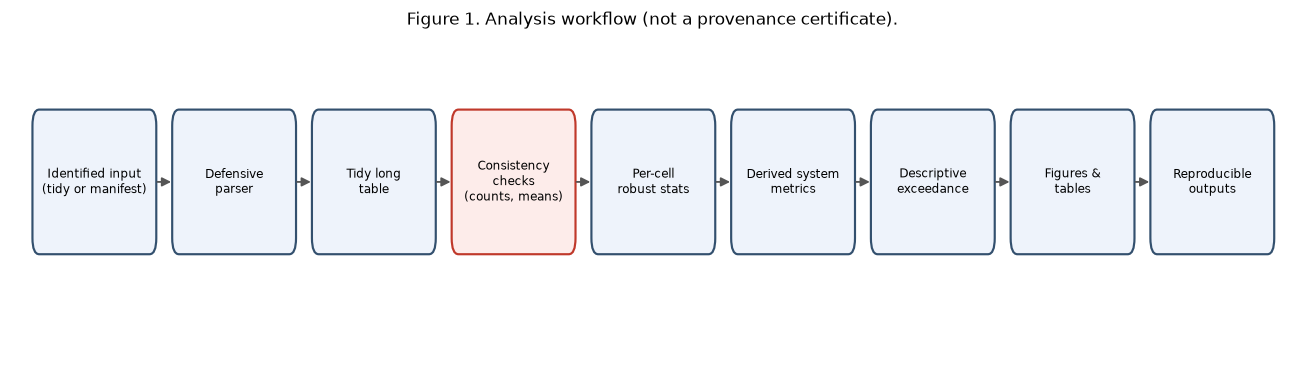

In [7]:
fig,ax=plt.subplots(figsize=(11,3.2)); ax.axis("off"); ax.grid(False)
stages=["Identified input\n(tidy or manifest)","Defensive\nparser","Tidy long\ntable","Consistency\nchecks\n(counts, means)",
        "Per-cell\nrobust stats","Derived system\nmetrics","Descriptive\nexceedance","Figures &\ntables","Reproducible\noutputs"]
n=len(stages); x0,w,gap,y,h=0.2,1.05,0.18,0.4,0.5
for i,s in enumerate(stages):
    x=x0+i*(w+gap)
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.06",
        fc="#fdecea" if i==3 else "#eef3fb", ec="#c0392b" if i==3 else "#33506e", lw=1.3))
    ax.text(x+w/2,y+h/2,s,ha="center",va="center",fontsize=7.4)
    if i<n-1: ax.add_patch(FancyArrowPatch((x+w,y+h/2),(x+w+gap,y+h/2),arrowstyle="-|>",mutation_scale=11,color="#555",lw=1.1))
ax.set_xlim(0,x0+n*(w+gap)); ax.set_ylim(0,1.2)
ax.set_title("Figure 1. Analysis workflow (not a provenance certificate).",fontsize=10)
plt.tight_layout(); plt.show()

### 5.0b Figure 2 — PQC-secured V2V/V2X architecture and measurement plane (schematic)

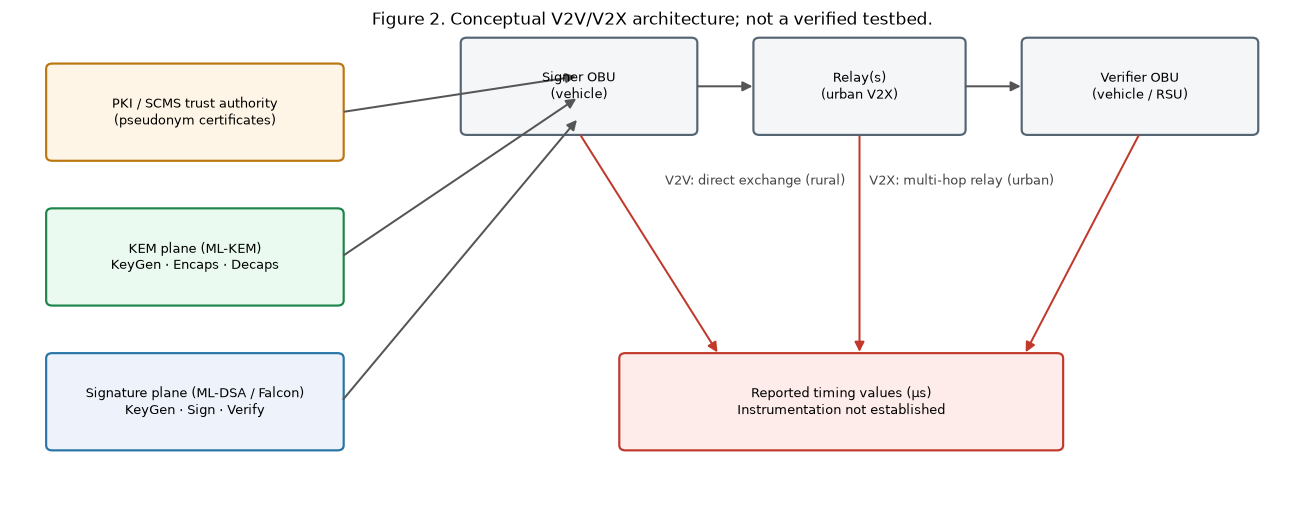

In [8]:
fig,ax=plt.subplots(figsize=(11,4.4)); ax.axis("off"); ax.grid(False)
def _box(x,y,w,h,t,fc,ec,fs=8):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.05",fc=fc,ec=ec,lw=1.3))
    ax.text(x+w/2,y+h/2,t,ha="center",va="center",fontsize=fs)
def _arr(p1,p2,c="#555"):
    ax.add_patch(FancyArrowPatch(p1,p2,arrowstyle="-|>",mutation_scale=12,color=c,lw=1.2))
_box(0.3,3.3,2.4,0.9,"PKI / SCMS trust authority\n(pseudonym certificates)","#fff5e6","#b9770e")
_box(0.3,1.9,2.4,0.9,"KEM plane (ML-KEM)\nKeyGen · Encaps · Decaps","#eafaf1","#1e8449")
_box(0.3,0.5,2.4,0.9,"Signature plane (ML-DSA / Falcon)\nKeyGen · Sign · Verify","#eef3fb","#2874a6")
_box(3.7,3.55,1.9,0.9,"Signer OBU\n(vehicle)","#f4f6f7","#566573")
_box(6.1,3.55,1.7,0.9,"Relay(s)\n(urban V2X)","#f4f6f7","#566573")
_box(8.3,3.55,1.9,0.9,"Verifier OBU\n(vehicle / RSU)","#f4f6f7","#566573")
_box(5.0,0.5,3.6,0.9,"Reported timing values (µs)\nInstrumentation not established","#fdecea","#c0392b",8)
_arr((2.7,3.75),(4.65,4.1)); _arr((2.7,2.35),(4.65,3.9)); _arr((2.7,0.95),(4.65,3.7))
_arr((5.6,4.0),(6.1,4.0)); _arr((7.8,4.0),(8.3,4.0))
_arr((4.65,3.55),(5.8,1.4),c="#c0392b"); _arr((6.95,3.55),(6.95,1.4),c="#c0392b"); _arr((9.25,3.55),(8.3,1.4),c="#c0392b")
ax.text(6.95,3.05,"V2V: direct exchange (rural)      V2X: multi-hop relay (urban)",fontsize=7.6,color="#444",ha="center")
ax.set_xlim(0,10.5); ax.set_ylim(0,4.5)
ax.set_title("Figure 2. Conceptual V2V/V2X architecture; not a verified testbed.",fontsize=10)
plt.tight_layout(); plt.show()

### 5.1 Latency distributions (per scenario, log scale) — Figures 3 & 4

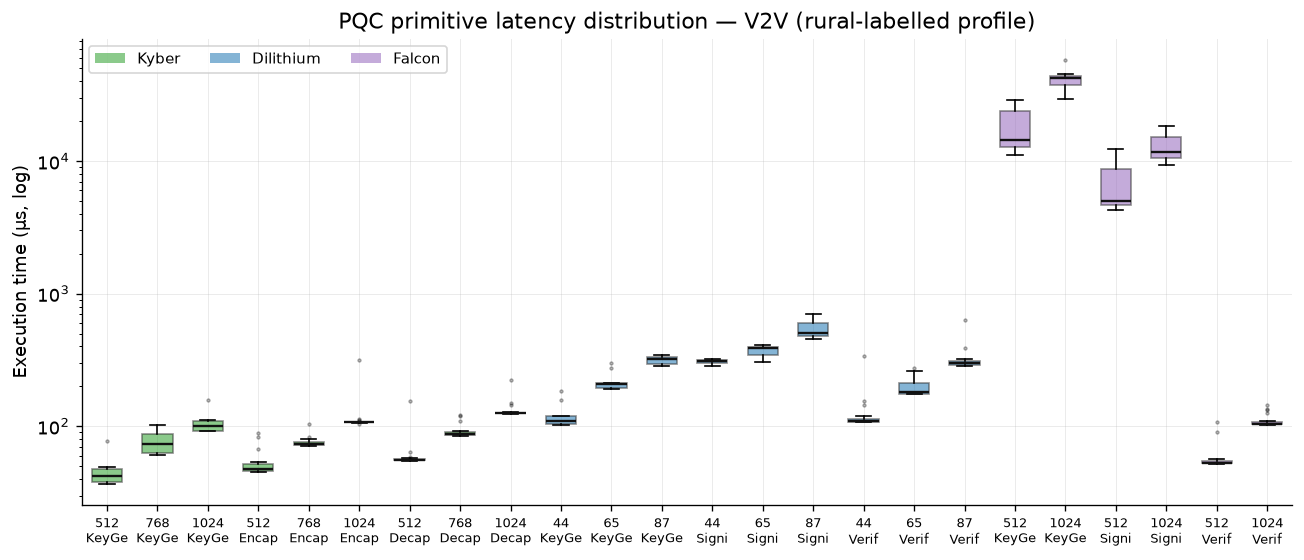

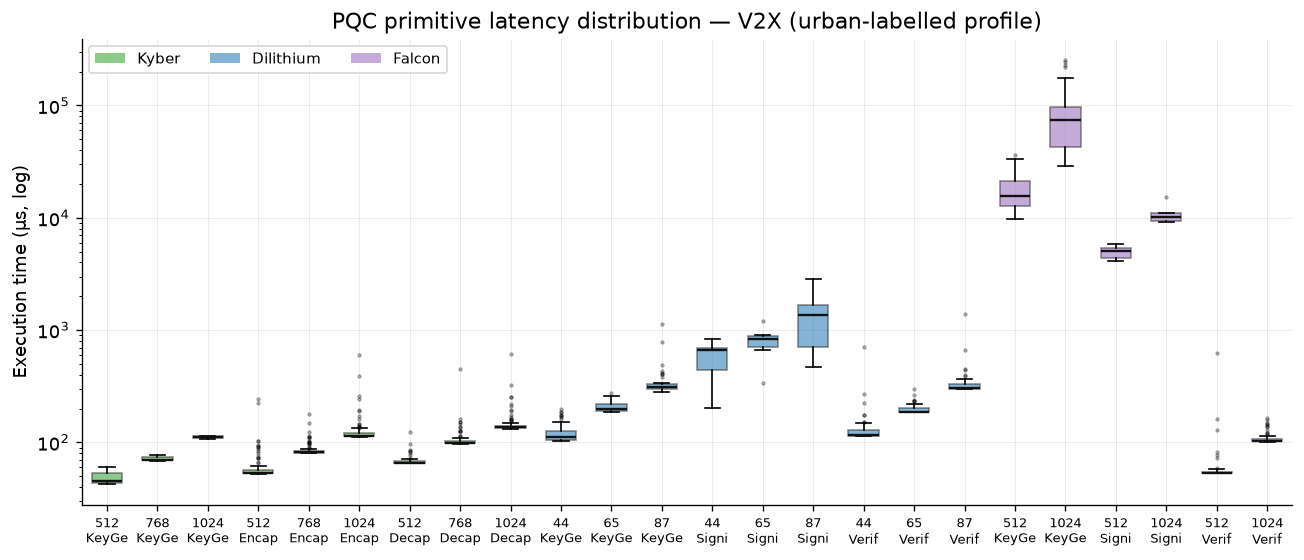

In [9]:
ALGO_ORDER=["Kyber","Dilithium","Falcon"]
OP_ORDER=["KeyGen","Encapsulation","Decapsulation","Signing","Verification"]
VAR_ORDER=["Kyber-512","Kyber-768","Kyber-1024","Dilithium-44","Dilithium-65","Dilithium-87","Falcon-512","Falcon-1024"]
ALGC={"Kyber":"#2ca02c","Dilithium":"#1f77b4","Falcon":"#9467bd"}; C={"V2V":"#1f77b4","V2X":"#d62728"}
for scen,lbl in [("V2V","rural"),("V2X","urban")]:
    fig,ax=plt.subplots(figsize=(11,4.8)); sub=df[df.scenario==scen]
    groups,ticklab,colors=[],[],[]
    for algo in ALGO_ORDER:
        for op in OP_ORDER:
            for var in [v for v in VAR_ORDER if v.startswith(algo)]:
                d=sub[(sub.operation==op)&(sub.variant==var)].time_us.values
                if len(d)==0: continue
                groups.append(d); ticklab.append(f"{var.split('-')[1]}\n{op[:5]}"); colors.append(ALGC[algo])
    bp=ax.boxplot(groups,positions=range(1,len(groups)+1),widths=0.6,patch_artist=True,flierprops=dict(marker='.',ms=3,alpha=0.4))
    for patch,c in zip(bp['boxes'],colors): patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor("#333")
    for m in bp['medians']: m.set_color("#111"); m.set_linewidth(1.4)
    ax.set_yscale("log"); ax.set_xticks(range(1,len(groups)+1)); ax.set_xticklabels(ticklab,fontsize=7.5)
    ax.set_ylabel("Execution time (µs, log)")
    ax.set_title(f"PQC primitive latency distribution — {scen} ({lbl}-labelled profile)")
    ax.legend(handles=[Patch(facecolor=ALGC[a],alpha=0.55,label=a) for a in ALGO_ORDER],ncol=3,loc="upper left",fontsize=9)
    plt.tight_layout(); plt.show()

### 5.2 Key-encapsulation (ML-KEM / Kyber) cost across security levels — Figure 5

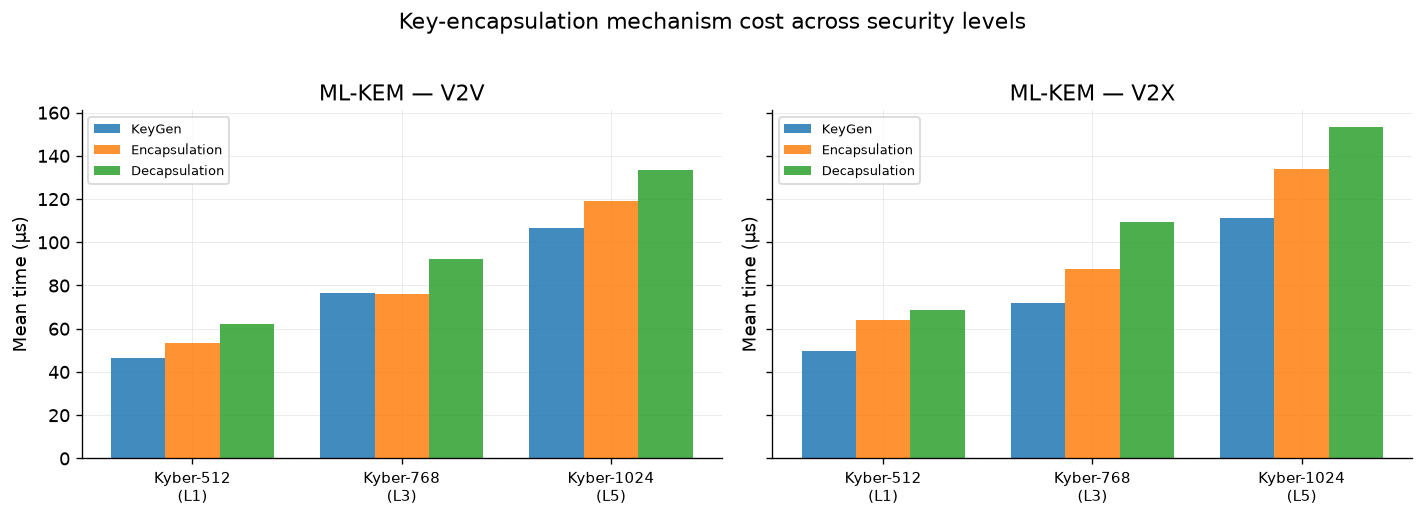

In [10]:
fig,axes=plt.subplots(1,2,figsize=(12,4.2),sharey=True)
for ax,scen in zip(axes,["V2V","V2X"]):
    variants=["Kyber-512","Kyber-768","Kyber-1024"]; ops=["KeyGen","Encapsulation","Decapsulation"]
    x=np.arange(len(variants)); w=0.26
    for j,op in enumerate(ops):
        means=[df[(df.scenario==scen)&(df.operation==op)&(df.variant==v)].time_us.mean() for v in variants]
        ax.bar(x+(j-1)*w,means,w,label=op,alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f"{v}\n({SEC[v]})" for v in variants],fontsize=9)
    ax.set_title(f"ML-KEM — {scen}"); ax.set_ylabel("Mean time (µs)"); ax.legend(fontsize=8)
plt.suptitle("Key-encapsulation mechanism cost across security levels",y=1.02); plt.tight_layout(); plt.show()

### 5.3 Signature operations (Dilithium vs Falcon), by scenario — Figure 6

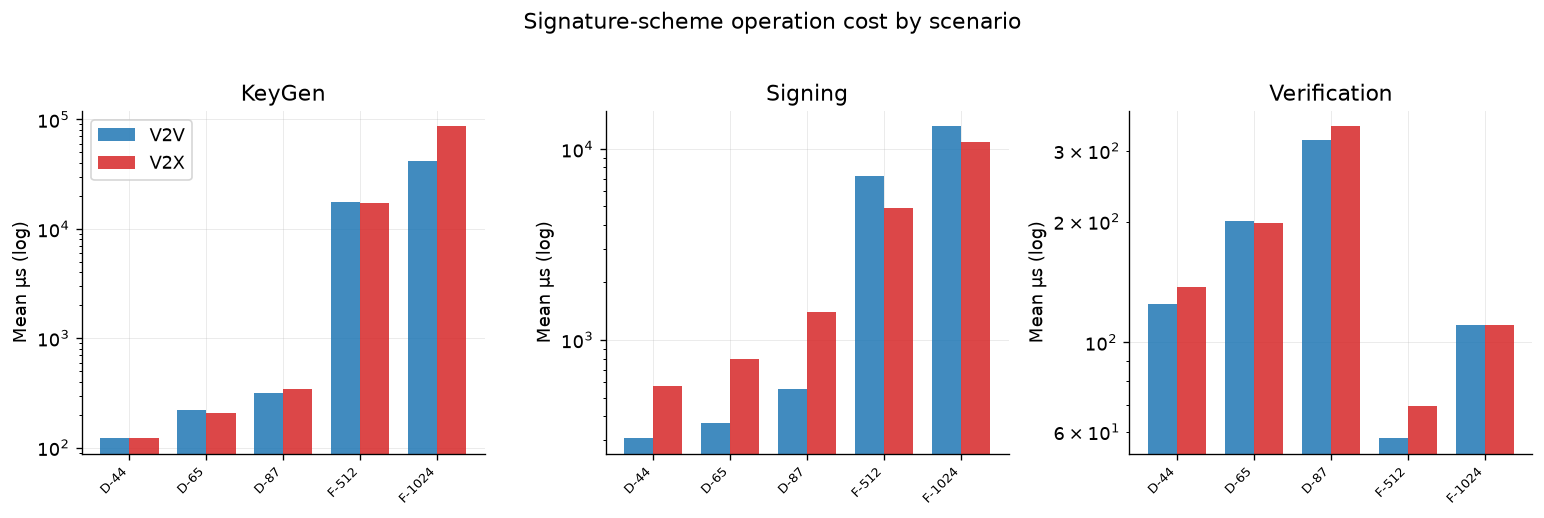

In [11]:
sig=df[df.algorithm.isin(["Dilithium","Falcon"])]
sigvars=[v for v in VAR_ORDER if v.startswith(("Dilithium","Falcon"))]
fig,axes=plt.subplots(1,3,figsize=(13,4.2))
for ax,op in zip(axes,["KeyGen","Signing","Verification"]):
    x=np.arange(len(sigvars)); w=0.38
    for i,scen in enumerate(["V2V","V2X"]):
        means=[sig[(sig.scenario==scen)&(sig.operation==op)&(sig.variant==v)].time_us.mean() for v in sigvars]
        ax.bar(x+(i-0.5)*w,means,w,label=scen,color=C[scen],alpha=0.85)
    ax.set_yscale("log"); ax.set_xticks(x)
    ax.set_xticklabels([v.replace("Dilithium","D").replace("Falcon","F") for v in sigvars],rotation=45,ha="right",fontsize=8)
    ax.set_title(op); ax.set_ylabel("Mean µs (log)")
    if op=="KeyGen": ax.legend()
plt.suptitle("Signature-scheme operation cost by scenario",y=1.02); plt.tight_layout(); plt.show()

### 5.4 Verification latency ECDF (safety-critical path) — Figure 7
Verification runs on **every** received message. Sample sizes are shown in the legend; the ECDF is the empirical distribution of the observed sample, not a fitted model.

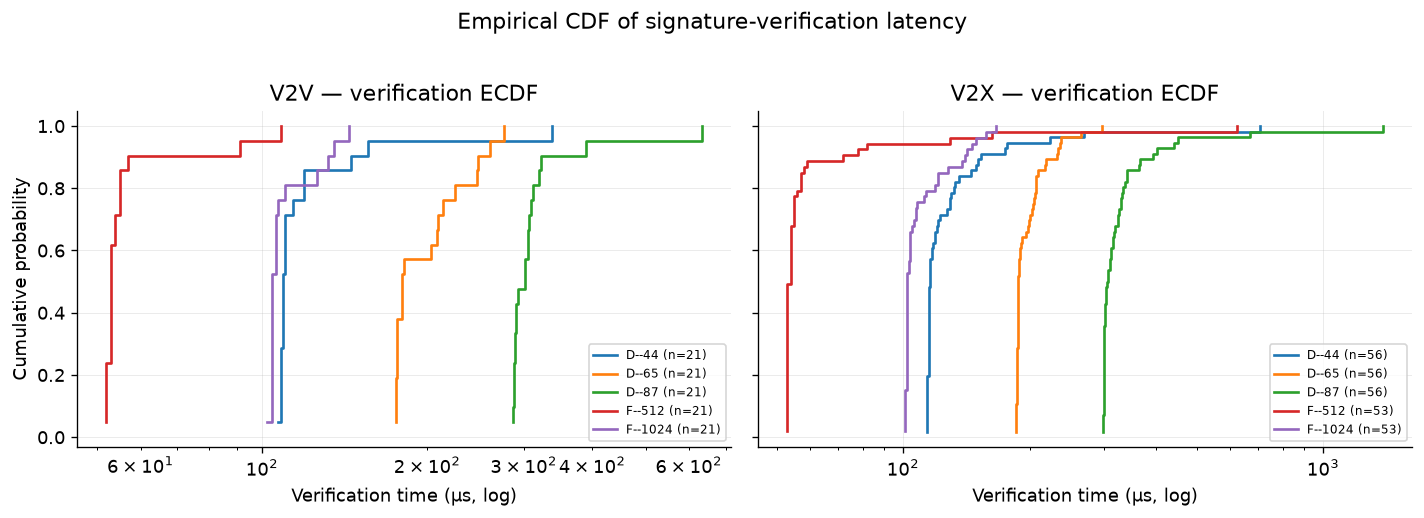

In [12]:
fig,axes=plt.subplots(1,2,figsize=(12,4.2),sharey=True)
for ax,scen in zip(axes,["V2V","V2X"]):
    for var in sigvars:
        d=np.sort(df[(df.scenario==scen)&(df.operation=="Verification")&(df.variant==var)].time_us.values)
        if len(d)==0: continue
        ax.step(d,np.arange(1,len(d)+1)/len(d),where="post",lw=1.6,
                label=f"{var} (n={len(d)})".replace("Dilithium","D-").replace("Falcon","F-"))
    ax.set_xscale("log"); ax.set_xlabel("Verification time (µs, log)")
    ax.set_title(f"{scen} — verification ECDF"); ax.legend(fontsize=7,loc="lower right")
axes[0].set_ylabel("Cumulative probability")
plt.suptitle("Empirical CDF of signature-verification latency",y=1.02); plt.tight_layout(); plt.show()

### 5.5 Tail latency: median vs p95 / p99 (with n) — Figure 8

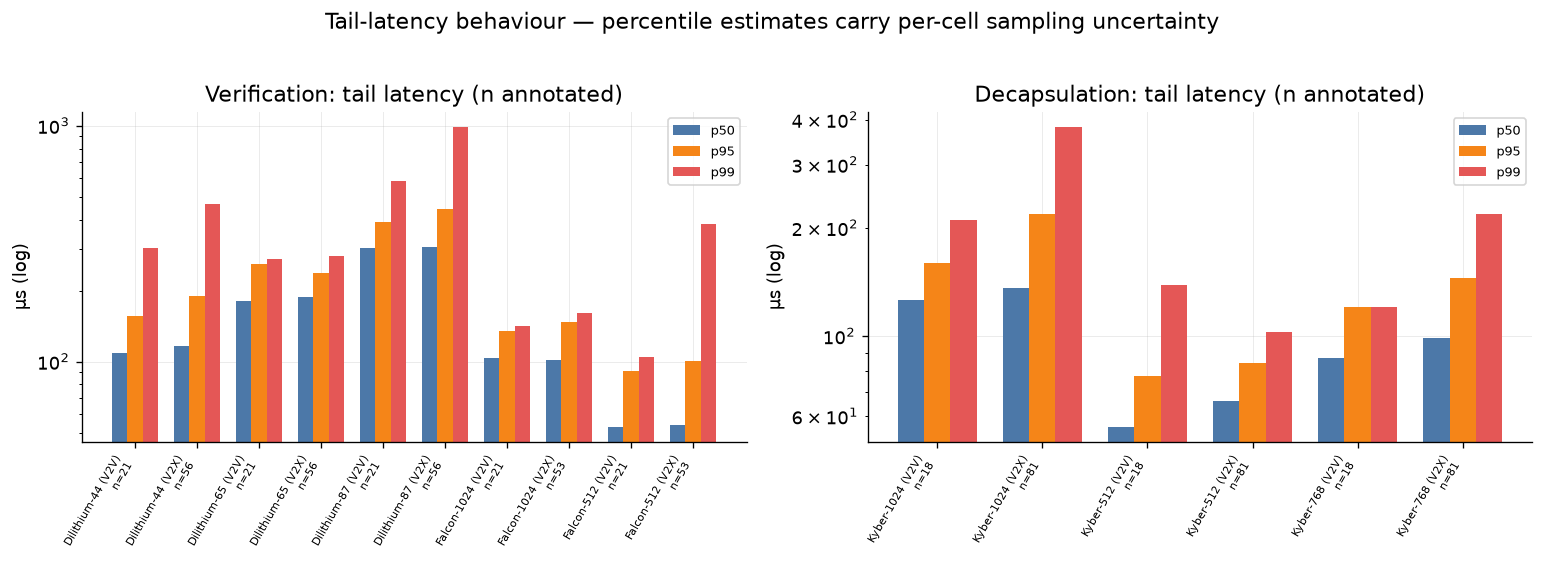

In [13]:
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
for ax,op in zip(axes,["Verification","Decapsulation"]):
    sub=summary[summary.operation==op].sort_values(["variant","scenario"])
    x=np.arange(len(sub))
    ax.bar(x-0.25,sub["median"],0.25,label="p50",color="#4c78a8")
    ax.bar(x,sub["p95"],0.25,label="p95",color="#f58518")
    ax.bar(x+0.25,sub["p99"],0.25,label="p99",color="#e45756")
    ax.set_yscale("log"); ax.set_xticks(x)
    ax.set_xticklabels([f"{r.variant} ({r.scenario})\nn={int(r.n)}" for _,r in sub.iterrows()],rotation=60,ha="right",fontsize=6.5)
    ax.set_title(f"{op}: tail latency (n annotated)"); ax.set_ylabel("µs (log)"); ax.legend(fontsize=8)
plt.suptitle("Tail-latency behaviour — percentile estimates carry per-cell sampling uncertainty",y=1.02)
plt.tight_layout(); plt.show()

### 5.6 Timing jitter (coefficient of variation) heatmap — Figure 9

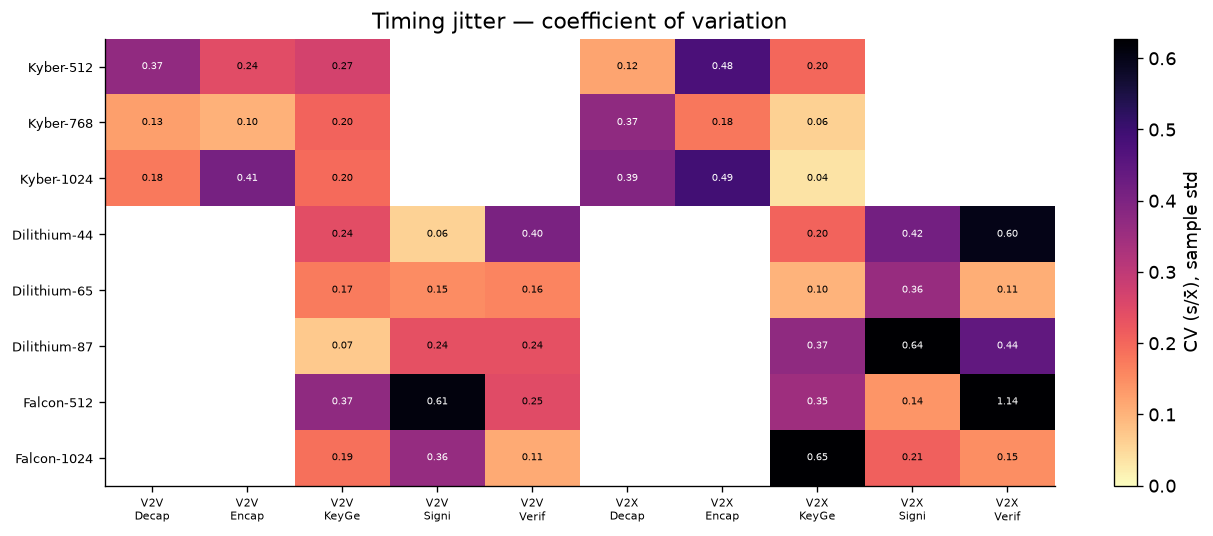

In [14]:
piv=summary.pivot_table(index="variant",columns=["scenario","operation"],values="cv").reindex(VAR_ORDER)
fig,ax=plt.subplots(figsize=(11,4.6)); data=piv.values.astype(float); ax.grid(False)
im=ax.imshow(data,aspect="auto",cmap="magma_r",vmin=0,vmax=np.nanpercentile(data,95))
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index,fontsize=8)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"{s}\n{o[:5]}" for s,o in piv.columns],fontsize=6.5)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i,j]):
            ax.text(j,i,f"{data[i,j]:.2f}",ha="center",va="center",fontsize=6,color="white" if data[i,j]>np.nanpercentile(data,60) else "black")
plt.colorbar(im,label="CV (s/x̄), sample std"); ax.set_title("Timing jitter — coefficient of variation"); plt.tight_layout(); plt.show()

### Figure 10 and Table 3 — reported packet sizes and arithmetic residuals

The five packet totals are retained constants attributed to the urban summary sheet by the supplied notebook; the source sheet is not independently verified. Subtracting public-key and reference signature sizes gives residuals of +8 bytes for each ML-DSA set, -2 for Falcon-512, and +1 for Falcon-1024. Their meaning is **unresolved**. In particular, +8 is not verified container overhead. Falcon's 666/1280-byte reference values are padded signature sizes; unpadded encodings also exist. Compression does not remove additivity of serialized byte counts.

,scheme,sec,public_key,reference_signature,component_sum,reported_total,unexplained_residual
0,Dilithium-44,L2,1312,2420,3732,3740,8
1,Dilithium-65,L3,1952,3309,5261,5269,8
2,Dilithium-87,L5,2592,4627,7219,7227,8
3,Falcon-512,L1,897,666,1563,1561,-2
4,Falcon-1024,L5,1793,1280,3073,3074,1


Arithmetic checked; source totals and encodings not independently verified.


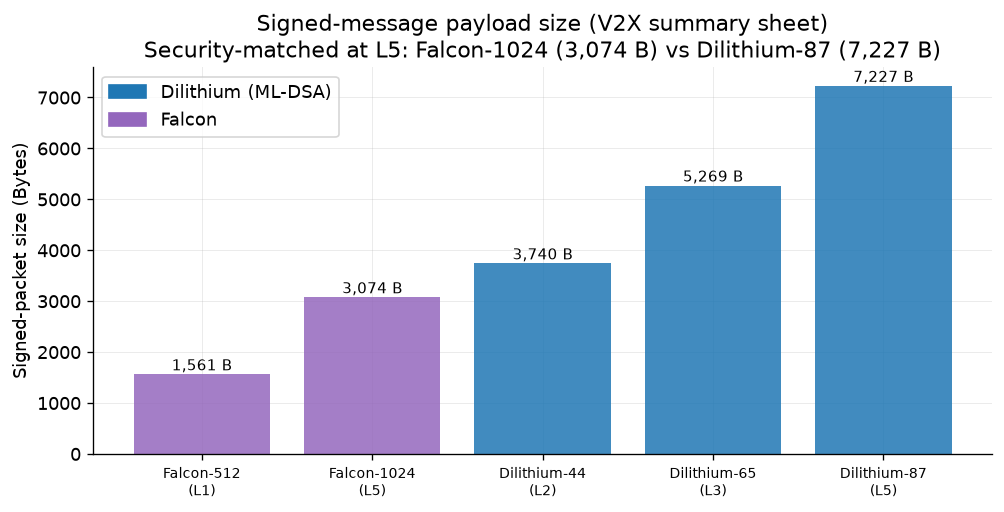

In [15]:
STD_SIZE={"Dilithium-44":(1312,2420),"Dilithium-65":(1952,3309),"Dilithium-87":(2592,4627),
          "Falcon-512":(897,666),"Falcon-1024":(1793,1280)}   # (public_key, signature) bytes
SHEET_PKT={"Dilithium-44":3740,"Dilithium-65":5269,"Dilithium-87":7227,"Falcon-512":1561,"Falcon-1024":3074}
rows=[]
for v,(pk,sg) in STD_SIZE.items():
    residual=SHEET_PKT[v]-pk-sg
    rows.append(dict(scheme=v,sec=SEC[v],public_key=pk,reference_signature=sg,
                     component_sum=pk+sg,reported_total=SHEET_PKT[v],unexplained_residual=residual))
pkt_tbl=pd.DataFrame(rows)
require(pkt_tbl.unexplained_residual.tolist()==[8,8,8,-2,1], "Packet residual arithmetic mismatch")
pkt_tbl.to_csv(OUT / "table_3_packet_arithmetic.csv",index=False)
display(pkt_tbl)
print("Arithmetic checked; source totals and encodings not independently verified.")

order=["Falcon-512","Falcon-1024","Dilithium-44","Dilithium-65","Dilithium-87"]
fig,ax=plt.subplots(figsize=(8.5,4.4)); vs=[SHEET_PKT[k] for k in order]
cols=[ALGC["Dilithium"] if "Dil" in k else ALGC["Falcon"] for k in order]
ax.bar(range(len(order)),vs,color=cols,alpha=0.85)
for i,v in enumerate(vs): ax.text(i,v+80,f"{v:,} B",ha="center",fontsize=9)
ax.set_xticks(range(len(order))); ax.set_xticklabels([f"{k}\n({SEC[k]})" for k in order],fontsize=8.5)
ax.set_ylabel("Signed-packet size (Bytes)")
ax.set_title("Signed-message payload size (V2X summary sheet)\nSecurity-matched at L5: Falcon-1024 (3,074 B) vs Dilithium-87 (7,227 B)")
ax.legend(handles=[Patch(color=ALGC["Dilithium"],label="Dilithium (ML-DSA)"),Patch(color=ALGC["Falcon"],label="Falcon")])
plt.tight_layout(); plt.show()

### 5.8 Aggregate primitive-operation cost — Figure 11 and Table 4

We report the **aggregate of the constituent per-operation means** (KeyGen + Encaps + Decaps for the KEM; KeyGen + Sign + Verify for the signatures). This is a bookkeeping sum of primitive costs, **not** a measured end-to-end handshake, and key generation is typically **amortised** (performed far less often than signing/verification) rather than paid per message. The estimator is fixed to *sum of means* throughout (a sum of medians is a different quantity and is not used).

Table 4 — aggregate primitive-operation cost (sum of means, µs):
scenario          V2V      V2X
variant                       
Kyber-512       162.0    182.0
Kyber-768       245.0    269.0
Kyber-1024      359.0    399.0
Dilithium-44    554.0    834.0
Dilithium-65    790.0   1203.0
Dilithium-87   1190.0   2083.0
Falcon-512    24777.0  22322.0
Falcon-1024   54794.0  97252.0

Note: V2V Kyber-512 sum-of-medians=145.50 µs vs sum-of-means=161.94 µs (different estimators).


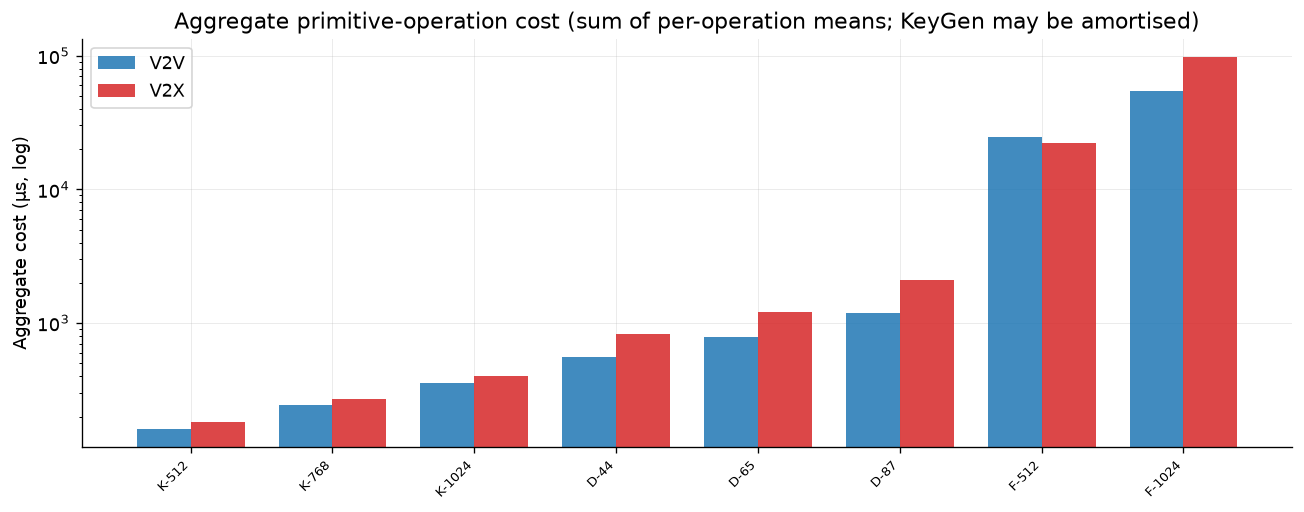

In [16]:
def cell(s,v,op,stat):
    r=summary[(summary.scenario==s)&(summary.variant==v)&(summary.operation==op)]
    return float(r[stat].iloc[0])
comp=[]
for scen in ["V2V","V2X"]:
    for v in VAR_ORDER:
        ops=["KeyGen","Encapsulation","Decapsulation"] if v.startswith("Kyber") else ["KeyGen","Signing","Verification"]
        comp.append((scen,v,sum(cell(scen,v,o,"mean") for o in ops)))
cdf=pd.DataFrame(comp,columns=["scenario","variant","total_us"])
table4=cdf.pivot(index="variant",columns="scenario",values="total_us").round(0).reindex(VAR_ORDER)
table4.to_csv(OUT / "table_4_aggregate_costs.csv")
print("Table 4 — aggregate primitive-operation cost (sum of means, µs):"); print(table4.to_string())
# contrast: sum of medians is a DIFFERENT quantity (illustrated for one cell)
sm=sum(cell("V2V","Kyber-512",o,"median") for o in ["KeyGen","Encapsulation","Decapsulation"])
print(f"\nNote: V2V Kyber-512 sum-of-medians={sm:.2f} µs vs sum-of-means={cdf.query('scenario==\"V2V\" and variant==\"Kyber-512\"').total_us.iloc[0]:.2f} µs (different estimators).")
fig,ax=plt.subplots(figsize=(11,4.4)); x=np.arange(len(VAR_ORDER)); w=0.38
for i,scen in enumerate(["V2V","V2X"]):
    ys=[cdf[(cdf.scenario==scen)&(cdf.variant==v)].total_us.values[0] for v in VAR_ORDER]
    ax.bar(x+(i-0.5)*w,ys,w,label=scen,color=C[scen],alpha=0.85)
ax.set_yscale("log"); ax.set_xticks(x)
ax.set_xticklabels([v.replace("Kyber","K").replace("Dilithium","D").replace("Falcon","F") for v in VAR_ORDER],rotation=45,ha="right",fontsize=8)
ax.set_ylabel("Aggregate cost (µs, log)")
ax.set_title("Aggregate primitive-operation cost (sum of per-operation means; KeyGen may be amortised)"); ax.legend()
plt.tight_layout(); plt.show()

### 5.9 Empirical exceedance vs verification budget — Figure 12
For a budget *b*, the plotted quantity is the **empirical fraction of measurements exceeding *b*** in that cell — a descriptive property of the sample, not a certified miss rate. Small n implies wide uncertainty (Section 4b).

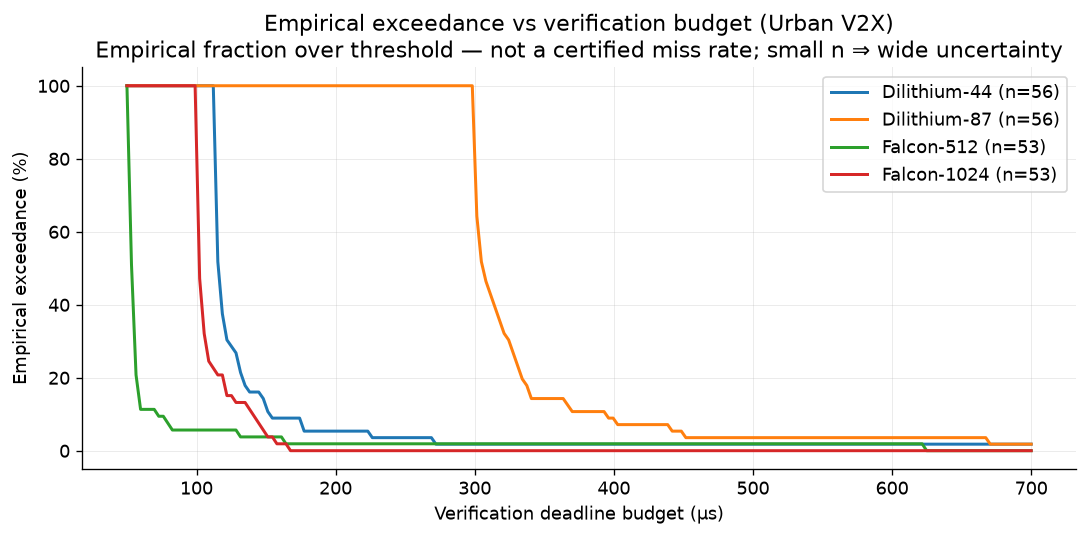

,scenario,variant,budget_us,n,exceedances,empirical_fraction,zero_failure_upper95
32,V2X,Dilithium-44,1000,56,0,0.000000,0.052090
33,V2X,Dilithium-44,5000,56,0,0.000000,0.052090
38,V2X,Dilithium-65,1000,56,0,0.000000,0.052090
39,V2X,Dilithium-65,5000,56,0,0.000000,0.052090
44,V2X,Dilithium-87,1000,56,1,0.017857,NaN
45,V2X,Dilithium-87,5000,56,0,0.000000,0.052090
50,V2X,Falcon-512,1000,53,0,0.000000,0.054955
51,V2X,Falcon-512,5000,53,0,0.000000,0.054955
56,V2X,Falcon-1024,1000,53,0,0.000000,0.054955
57,V2X,Falcon-1024,5000,53,0,0.000000,0.054955


In [17]:
fig,ax=plt.subplots(figsize=(9.2,4.6)); budgets=np.linspace(50,700,200)
for var in ["Dilithium-44","Dilithium-87","Falcon-512","Falcon-1024"]:
    d=df[(df.scenario=="V2X")&(df.operation=="Verification")&(df.variant==var)].time_us.values
    ax.plot(budgets,[(d>b).mean()*100 for b in budgets],lw=1.8,label=f"{var} (n={len(d)})")
ax.set_xlabel("Verification deadline budget (µs)"); ax.set_ylabel("Empirical exceedance (%)")
ax.set_title("Empirical exceedance vs verification budget (Urban V2X)\nEmpirical fraction over threshold — not a certified miss rate; small n ⇒ wide uncertainty")
ax.legend(); plt.tight_layout(); plt.show()
# Complete threshold audit for all five signature sets, separately from the original four-series plot.
thresholds=[]
for scen in ["V2V","V2X"]:
    for var in sigvars:
        values=df[(df.scenario==scen)&(df.variant==var)&(df.operation=="Verification")].time_us.to_numpy()
        for budget in [350,700,1000,5000,20000,100000]:
            failures=int(np.sum(values>budget)); n=len(values)
            thresholds.append(dict(scenario=scen,variant=var,budget_us=budget,n=n,exceedances=failures,
                                   empirical_fraction=failures/n,
                                   zero_failure_upper95=upper_bound_zero_failures(n) if failures==0 else np.nan))
threshold_table=pd.DataFrame(thresholds)
threshold_table.to_csv(OUT / "verification_threshold_counts.csv",index=False)
display(threshold_table.query("scenario=='V2X' and budget_us in [1000,5000]"))

### 5.10 Cross-scenario sensitivity of the median — Figure 13
The median is scenario-stable for **verification** but **not** for all operations: signing medians rise markedly from V2V to V2X. This figure plots the per-operation median ratio (V2X ÷ V2V).

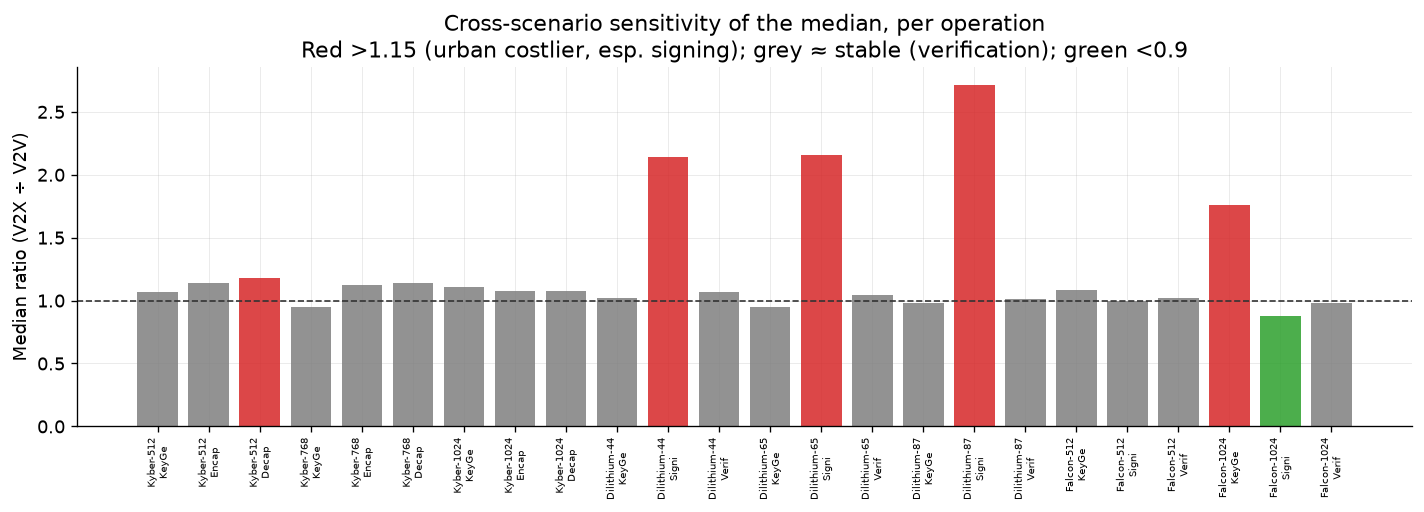

In [18]:
rows=[]
for v in VAR_ORDER:
    for op in OP_ORDER:
        a=summary[(summary.scenario=="V2V")&(summary.variant==v)&(summary.operation==op)]
        b=summary[(summary.scenario=="V2X")&(summary.variant==v)&(summary.operation==op)]
        if len(a) and len(b): rows.append((f"{v}\n{op[:5]}", b["median"].iloc[0]/a["median"].iloc[0]))
labels=[r[0] for r in rows]; ratios=[r[1] for r in rows]
fig,ax=plt.subplots(figsize=(12,4.4))
cols=["#d62728" if r>1.15 else ("#2ca02c" if r<0.9 else "#7f7f7f") for r in ratios]
ax.bar(range(len(ratios)),ratios,color=cols,alpha=0.85); ax.axhline(1.0,color="#333",lw=1,ls="--")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels,rotation=90,fontsize=6)
ax.set_ylabel("Median ratio (V2X ÷ V2V)")
ax.set_title("Cross-scenario sensitivity of the median, per operation\nRed >1.15 (urban costlier, esp. signing); grey ≈ stable (verification); green <0.9")
plt.tight_layout(); plt.show()

### 5.11 Median latency landscape — Figure 14

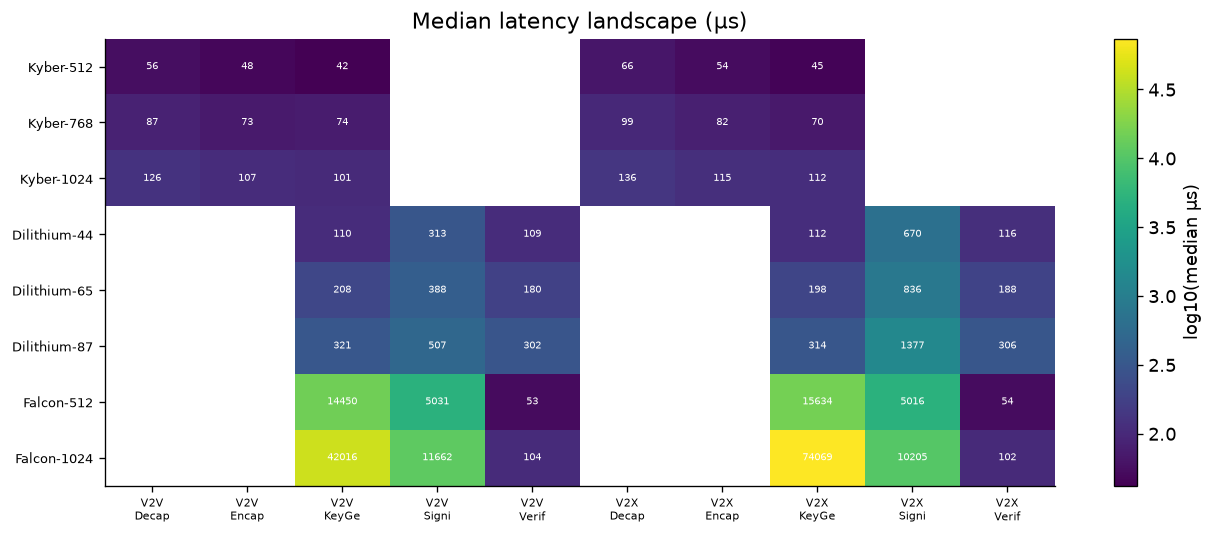

In [19]:
piv2=summary.pivot_table(index="variant",columns=["scenario","operation"],values="median").reindex(VAR_ORDER)
fig,ax=plt.subplots(figsize=(11,4.6)); data=np.log10(piv2.values.astype(float)); ax.grid(False)
im=ax.imshow(data,aspect="auto",cmap="viridis")
ax.set_yticks(range(len(piv2.index))); ax.set_yticklabels(piv2.index,fontsize=8)
ax.set_xticks(range(len(piv2.columns))); ax.set_xticklabels([f"{s}\n{o[:5]}" for s,o in piv2.columns],fontsize=6.5)
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]):
        val=piv2.values[i,j]
        if not np.isnan(val): ax.text(j,i,f"{val:.0f}",ha="center",va="center",fontsize=6,color="white")
plt.colorbar(im,label="log10(median µs)"); ax.set_title("Median latency landscape (µs)"); plt.tight_layout(); plt.show()

### 5.12 Idealised verification service rate — Figure 15
The reciprocal of latency is a **descriptive speed indicator**, not measured sustained throughput. Using the *mean* (which reflects the tail), the urban Dilithium-87 idealised rate falls **below** an illustrative 300-neighbour × 10 Hz = 3,000 arrivals/s load — before queueing, certificate checks, communication and application work. A sustained-load or queueing study is required for any capacity claim.

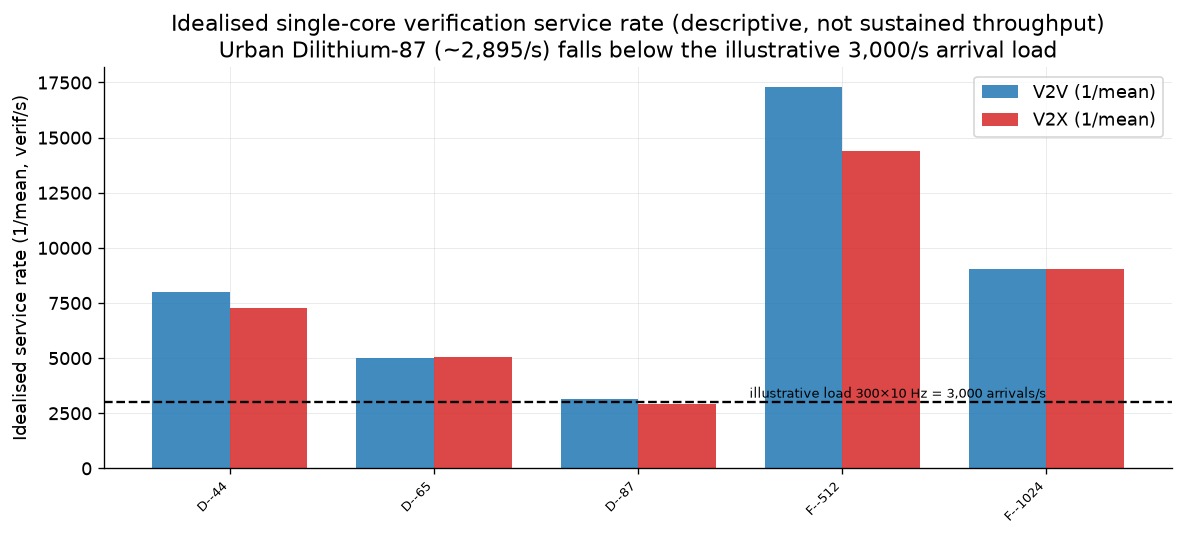

In [20]:
fig,ax=plt.subplots(figsize=(10,4.6)); x=np.arange(len(sigvars)); w=0.38
for i,scen in enumerate(["V2V","V2X"]):
    rate=[1e6/cell(scen,v,"Verification","mean") for v in sigvars]
    ax.bar(x+(i-0.5)*w,rate,w,label=f"{scen} (1/mean)",color=C[scen],alpha=0.85)
ax.axhline(3000,color="#000",lw=1.4,ls="--")
ax.text(len(sigvars)-1,3200,"illustrative load 300×10 Hz = 3,000 arrivals/s",ha="right",fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([v.replace("Dilithium","D-").replace("Falcon","F-") for v in sigvars],rotation=45,ha="right",fontsize=8)
ax.set_ylabel("Idealised service rate (1/mean, verif/s)")
ax.set_title("Idealised single-core verification service rate (descriptive, not sustained throughput)\nUrban Dilithium-87 (~2,895/s) falls below the illustrative 3,000/s arrival load")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Headline findings — computed and asserted

The cell below prints the quantitative claims used in the manuscript and **asserts** them against the corpus, so the paper and the code cannot silently diverge.

In [21]:
def med(s,v,op): return cell(s,v,op,"median")
def mean(s,v,op): return cell(s,v,op,"mean")

ver_med=summary[summary.operation=="Verification"]["median"]
print("Verification median range: %.1f–%.1f µs (all schemes/scenarios)" % (ver_med.min(), ver_med.max()))
require(ver_med.min()==53 and ver_med.max()==306.5,"Verification median range mismatch")

r=med("V2V","Falcon-512","KeyGen")/med("V2V","Dilithium-44","KeyGen")
print("Falcon-512 vs Dilithium-44 KeyGen (V2V medians): %.0f vs %.0f µs (%.0fx)" %
      (med("V2V","Falcon-512","KeyGen"),med("V2V","Dilithium-44","KeyGen"),r))
assert 120<=r<=140

print("Dilithium signing median shifts V2V->V2X: D-44 %.0f->%.0f, D-87 %.0f->%.0f µs" %
      (med("V2V","Dilithium-44","Signing"),med("V2X","Dilithium-44","Signing"),
       med("V2V","Dilithium-87","Signing"),med("V2X","Dilithium-87","Signing")))
assert med("V2X","Dilithium-44","Signing")>med("V2V","Dilithium-44","Signing")

f99v,f99x=cell("V2V","Falcon-512","Signing","p99"),cell("V2X","Falcon-512","Signing","p99")
print("Falcon-512 signing p99 V2V=%.0f -> V2X=%.0f µs (tail does NOT rise uniformly; n=3/6)" % (f99v,f99x))
assert f99x<f99v

d87=1e6/mean("V2X","Dilithium-87","Verification")
print("Urban Dilithium-87 idealised service rate (1/mean) = %.0f verif/s vs 3,000/s illustrative load" % d87)
assert d87<3000

worst=summary.sort_values("cv",ascending=False).iloc[0]
print("Highest-jitter cell: %s %s %s  CV=%.2f (median %.0f, p99 %.0f µs, n=%d)" %
      (worst.scenario,worst.variant,worst.operation,worst.cv,worst["median"],worst["p99"],int(worst.n)))
print("\nAll headline-finding assertions passed.")
require(int(threshold_table.query("scenario=='V2X' and variant=='Dilithium-87' and budget_us==1000").exceedances.iloc[0])==1,"1-ms exceedance changed")
require(threshold_table.query("budget_us==5000").exceedances.sum()==0,"5-ms verification exceedance changed")
service=summary.query("operation=='Verification'")[["scenario","variant","n","mean"]].copy()
service["idealized_verifications_per_second"]=1e6/service["mean"]
service.to_csv(OUT / "verification_service_rates.csv",index=False)
require(fig_counter==15,"Expected 15 exported figures")
VALIDATION["analysis_assertions"]="PASS"
VALIDATION["figure_exports"]="PASS: 15 figures in PNG and PDF"
(OUT / "validation_report.json").write_text(json.dumps(VALIDATION,indent=2))
print(json.dumps(VALIDATION,indent=2))

Verification median range: 53.0–306.5 µs (all schemes/scenarios)
Falcon-512 vs Dilithium-44 KeyGen (V2V medians): 14450 vs 110 µs (131x)
Dilithium signing median shifts V2V->V2X: D-44 313->670, D-87 507->1377 µs
Falcon-512 signing p99 V2V=12092 -> V2X=5797 µs (tail does NOT rise uniformly; n=3/6)
Urban Dilithium-87 idealised service rate (1/mean) = 2895 verif/s vs 3,000/s illustrative load
Highest-jitter cell: V2X Falcon-512 Verification  CV=1.14 (median 54, p99 383 µs, n=53)

All headline-finding assertions passed.
{
  "original_experiment": "NOT_VERIFIED",
  "source_pdf_transcription": "NOT_VERIFIED",
  "raw_to_tidy": "NOT_RUN: original raw files not supplied",
  "input_identity": "PASS: bundled tidy checksum",
  "cell_counts": "PASS: 48 cells and all expected per-cell counts",
  "reference_means": "PASS: 48 supplied constants within absolute tolerance 5e-6 us",
  "analysis_assertions": "PASS",
  "figure_exports": "PASS: 15 figures in PNG and PDF"
}
